<a href="https://colab.research.google.com/github/Karsuman4298/Generative-AI/blob/main/nanoVLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [244]:
import torch,math,random
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from PIL import Image,ImageDraw
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

In [245]:
IMG_SIZE=32
EMBED_DIM=256
ATTENTION_HEAD=64
BATCH_SIZE=12
EPOCH=100
LR=2e-4
TEMPERATURE=0.08
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')




# SYNTHETIC DATASET

In [246]:
color=['red','green','blue','yellow','purple','orange','pink','brown','grey']
shapes=['square','circle','rectangle']
positions=['left','center','right','top','bottom','top-left','top-right','bottom-left','bottom-right']

# DRAWING IMAGE SHAPES

In [247]:

def draw_sample(color, position, shape, img_size=IMG_SIZE):
  img=Image.new('RGB',(img_size,img_size),'white')
  draw=ImageDraw.Draw(img)
  margin=6
  h=w=img_size-2*margin

  # Calculate x coordinates
  if 'left' in position:
      x0 = margin
      x1 = margin + w // 2
  elif 'top-left' in position:
      x0 = margin
      x1 = margin + w // 2
  elif 'bottom-left' in position:
      x0 = margin
      x1 = margin + w // 2
  elif 'right' in position:
      x0 = margin + w // 2
      x1 = img_size - margin
  elif 'top-right' in position:
      x0 = margin + w // 2
      x1 = img_size - margin
  elif 'bottom-right' in position:
      x0 = margin + w // 2
      x1 = img_size - margin
  else: # center or vertical positions
      x0 = margin + w // 4
      x1 = margin + 3 * w // 4

  # Calculate y coordinates
  if 'top' in position:
      y0 = margin
      y1 = margin + h // 2
  elif 'top-left' in position:
      y0 = margin
      y1 = margin + h // 2
  elif 'top-right' in position:
      y0 = margin
      y1 = margin + h // 2
  elif 'bottom' in position:
      y0 = margin + h // 2
      y1 = img_size - margin
  elif 'bottom-left' in position:
      y0 = margin + h // 2
      y1 = img_size - margin
  elif 'bottom-right' in position:
      y0 = margin + h // 2
      y1 = img_size - margin
  else: # center or horizontal positions
      y0 = margin + h // 4
      y1 = margin + 3 * h // 4

  if shape == 'square':
      draw.rectangle([x0, y0, x1, y1], fill=color, outline='black')
  elif shape == 'circle':
      draw.ellipse([x0, y0, x1, y1], fill=color, outline='black')
  else: # triangle
      draw.polygon([(x0 + (x1 - x0) // 2, y0), (x0, y1), (x1, y1)], fill=color, outline='black')
  return img

In [248]:
class ShapeDataset:
    def __init__(self, image_size=64):
        self.image = []
        self.captions = []
        self.image_size = image_size

        for c in color:          # Fixed: changed 'colors' to 'color'
            for p in positions:
                for s in shapes:
                    img_np = draw_sample(c, p, s, img_size=image_size)
                    # Convert to tensor (CHW, normalized to [0,1])
                    img_tensor = (
                        torch.from_numpy(np.asarray(img_np))
                        .permute(2, 0, 1)      # HWC → CHW
                        .float() / 255.0       # ← fixed: / instead of //
                    )
                    self.image.append(img_tensor)
                    self.captions.append(f"{c} {s} {p}")

        # Build vocabulary
        self.vocab, self.word2idx = self.build_vocab(self.captions)

    def build_vocab(self, texts):
        words = sorted({word for text in texts for word in text.split()})
        vocab = ['[CLS]'] + words
        w2i = {w: i for i, w in enumerate(vocab)}
        return vocab, w2i

    def encode_text(self, text):
        toks = [self.word2idx['[CLS]']] + [self.word2idx[word] for word in text.split()]
        return torch.tensor(toks, dtype=torch.long)

    def __len__(self):
        return len(self.image)

    def __getitem__(self, idx):
        return self.image[idx], self.encode_text(self.captions[idx])

In [249]:
full_ds=ShapeDataset()
VOCAB_SIZE=len(full_ds.vocab)
print(VOCAB_SIZE)
print(full_ds.vocab)
print(full_ds.captions)


22
['[CLS]', 'blue', 'bottom', 'bottom-left', 'bottom-right', 'brown', 'center', 'circle', 'green', 'grey', 'left', 'orange', 'pink', 'purple', 'rectangle', 'red', 'right', 'square', 'top', 'top-left', 'top-right', 'yellow']
['red square left', 'red circle left', 'red rectangle left', 'red square center', 'red circle center', 'red rectangle center', 'red square right', 'red circle right', 'red rectangle right', 'red square top', 'red circle top', 'red rectangle top', 'red square bottom', 'red circle bottom', 'red rectangle bottom', 'red square top-left', 'red circle top-left', 'red rectangle top-left', 'red square top-right', 'red circle top-right', 'red rectangle top-right', 'red square bottom-left', 'red circle bottom-left', 'red rectangle bottom-left', 'red square bottom-right', 'red circle bottom-right', 'red rectangle bottom-right', 'green square left', 'green circle left', 'green rectangle left', 'green square center', 'green circle center', 'green rectangle center', 'green squar

# Train - val

In [250]:
train_size=int(0.8 * len(full_ds))
val_size=len(full_ds) - train_size
train_ds,val_ds=torch.utils.data.random_split(full_ds,[train_size,val_size])

In [251]:
train_size,val_size

(194, 49)

In [252]:
train_loader=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False)

# Sample datapoint


green green square top-left


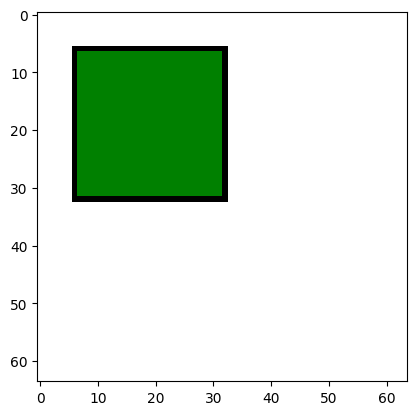

In [253]:
img_batch, caps_batch = next(iter(train_loader))
idx = random.randint(0, len(img_batch) - 1)
plt.imshow(img_batch[idx].permute(1, 2, 0))
print(full_ds.vocab[caps_batch[idx][1]], ' '.join([full_ds.vocab[i.item()] for i in caps_batch[idx][1:]]))

# Image Encoder

In [254]:
class ImageEncoder(nn.Module):
    def __init__(self,EMBED_DIM=EMBED_DIM):
        super().__init__()
        self.convolutions=nn.Sequential(
            nn.Conv2d(3,32,kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64,kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,128,kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(128,256,kernel_size=3,stride=2,padding=1),
            nn.ReLU()
        )

        self.projection=nn.Linear(256,EMBED_DIM)
        self.layer_norm=nn.LayerNorm(EMBED_DIM)

    def forward(self,x):
      x=self.convolutions(x)
      x=x.mean(dim=[2,3])
      x=self.projection(x)
      x=F.normalize(self.layer_norm(x),dim=-1) # Fixed typo
      return x

# Text Encoder



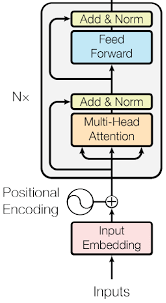

In [255]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, max_len=32):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.position_embedding = nn.Embedding(max_len, embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads=4)
        self.fc = nn.Linear(embed_dim, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, toks):
        N, L = toks.shape

        tok_emb = self.token_embedding(toks)
        pos = torch.arange(L, device=toks.device)
        pos_emb = self.position_embedding(pos)[None, :, :]

        x = tok_emb + pos_emb

        x = x.transpose(0,1)
        x, _ = self.attn(x, x, x)
        x = x.transpose(0,1)

        x = x.mean(dim=1)  # pooling

        x = self.fc(x)
        x = self.norm(x)

        return x

#CLIP Loss

In [256]:
def contrastive_loss(img_emb, txt_emb, temperature=0.07):
    logits = img_emb @ txt_emb.T / temperature
    labels = torch.arange(len(img_emb), device=img_emb.device)

    loss_i = F.cross_entropy(logits, labels)
    loss_t = F.cross_entropy(logits.T, labels)

    return (loss_i + loss_t) / 2

#Model , data, optimizer

In [257]:
img_enc=ImageEncoder().to(device)
txt_enc=TextEncoder(VOCAB_SIZE, EMBED_DIM).to(device)
params=list(img_enc.parameters())+list(txt_enc.parameters())
optimizer=torch.optim.Adam(params,lr=LR)

In [258]:
def show_img(t,titile=None):
  img=(t.permute(1,2,0).numpy()*255).astype(np.uint8)
  plt.figure(figsize=(2.2,2.2))
  plt.axis('off')
  if titile:
    plt.title(titile)
  plt.imshow(img)
  plt.show()


Sample image and caption for embedding vizualization:'orange rectangle right' 


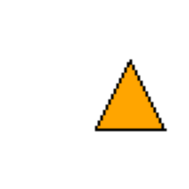

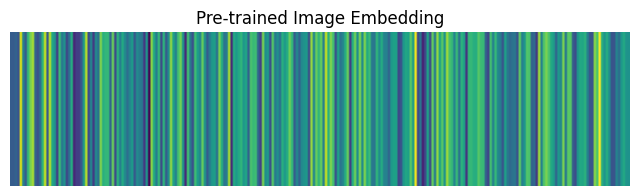

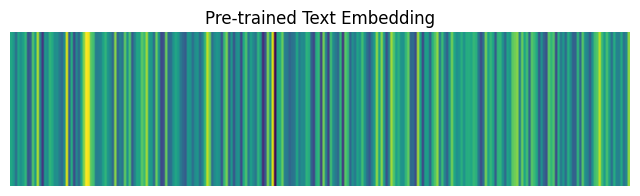

In [259]:
img_enc=ImageEncoder().to(device)
txt_enc=TextEncoder(VOCAB_SIZE, EMBED_DIM).to(device)

img_enc.eval(); txt_enc.eval()

with torch.no_grad():
  #select random indexes
  random_idx=random.randrange(len(full_ds))
  sample_img,sample_tok=full_ds[random_idx]
  sample_cap = full_ds.captions[random_idx]
  sample_img=sample_img.unsqueeze(0).to(device)
  sample_tok=sample_tok.unsqueeze(0).to(device)
  pre_train_img_emb=img_enc(sample_img).squeeze(0).cpu().numpy()
  pre_train_txt_emb=txt_enc(sample_tok).squeeze(0).cpu().numpy()


  print(f"Sample image and caption for embedding vizualization:'{sample_cap}' ")
  show_img(sample_img.squeeze(0).cpu())



  def plot_embedding(embedding,title):
    plt.figure(figsize=(8,2))
    plt.imshow(embedding.reshape(1,-1),aspect='auto',cmap='viridis')
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_embedding(pre_train_img_emb,'Pre-trained Image Embedding')
plot_embedding(pre_train_txt_emb,'Pre-trained Text Embedding')


# Training Loop

Epoch 01 | Train 6.1802 | Val 2.7858 | LR 2.00e-04


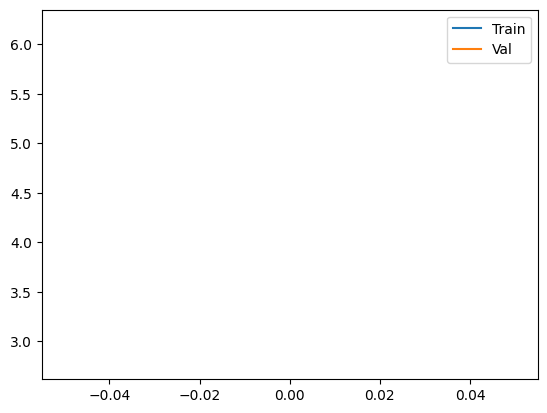

Epoch 02 | Train 2.5284 | Val 1.9572 | LR 2.00e-04
Epoch 03 | Train 2.1390 | Val 1.5492 | LR 2.00e-04
Epoch 04 | Train 1.4694 | Val 1.1003 | LR 1.99e-04
Epoch 05 | Train 1.0867 | Val 0.7635 | LR 1.99e-04
Epoch 06 | Train 0.7353 | Val 0.5868 | LR 1.98e-04
Epoch 07 | Train 0.6015 | Val 0.6797 | LR 1.98e-04
Epoch 08 | Train 0.4459 | Val 0.4431 | LR 1.97e-04
Epoch 09 | Train 0.5459 | Val 0.2096 | LR 1.96e-04
Epoch 10 | Train 0.3053 | Val 0.1978 | LR 1.95e-04
Epoch 11 | Train 0.2904 | Val 0.2685 | LR 1.94e-04


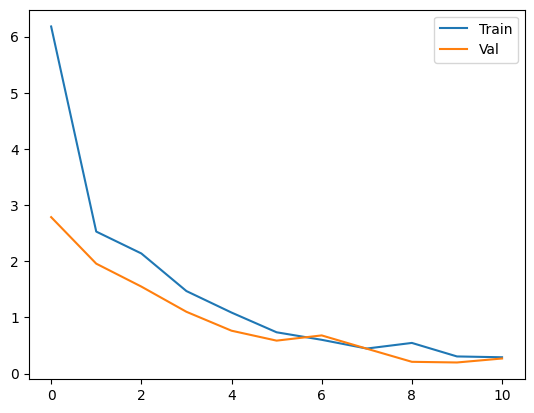

Epoch 12 | Train 0.3203 | Val 0.1963 | LR 1.93e-04
Epoch 13 | Train 0.2634 | Val 0.1209 | LR 1.92e-04
Epoch 14 | Train 0.2334 | Val 0.6381 | LR 1.90e-04
Epoch 15 | Train 0.4416 | Val 0.2117 | LR 1.89e-04
Epoch 16 | Train 0.2803 | Val 0.3777 | LR 1.88e-04
Epoch 17 | Train 0.2393 | Val 0.1007 | LR 1.86e-04
Epoch 18 | Train 0.1234 | Val 0.0692 | LR 1.84e-04
Epoch 19 | Train 0.1627 | Val 0.1004 | LR 1.83e-04
Epoch 20 | Train 0.1927 | Val 0.2099 | LR 1.81e-04
Epoch 21 | Train 0.1356 | Val 0.1124 | LR 1.79e-04


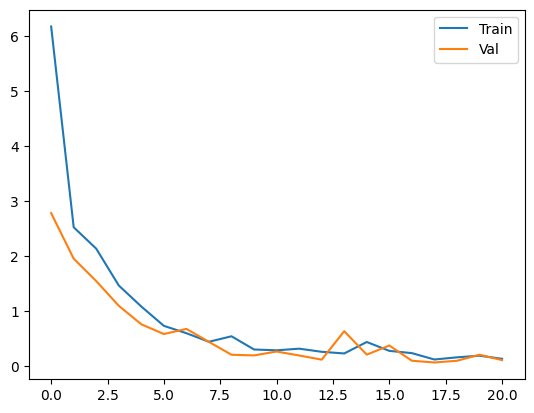

Epoch 22 | Train 0.0868 | Val 0.1370 | LR 1.77e-04
Epoch 23 | Train 0.2486 | Val 0.0751 | LR 1.75e-04
Epoch 24 | Train 0.0573 | Val 0.3593 | LR 1.73e-04
Epoch 25 | Train 0.1471 | Val 0.0425 | LR 1.71e-04
Epoch 26 | Train 0.0635 | Val 0.0774 | LR 1.68e-04
Epoch 27 | Train 0.1821 | Val 0.2218 | LR 1.66e-04
Epoch 28 | Train 0.2397 | Val 0.0642 | LR 1.64e-04
Epoch 29 | Train 0.0783 | Val 0.0655 | LR 1.61e-04
Epoch 30 | Train 0.0847 | Val 0.0700 | LR 1.59e-04
Epoch 31 | Train 0.0903 | Val 0.0338 | LR 1.56e-04


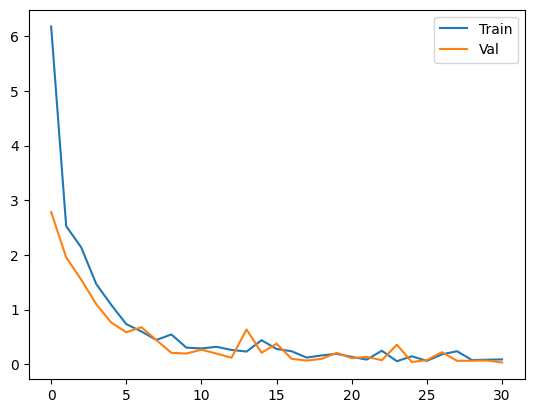

Epoch 32 | Train 0.0791 | Val 0.0005 | LR 1.54e-04
Epoch 33 | Train 0.0739 | Val 0.0460 | LR 1.51e-04
Epoch 34 | Train 0.0491 | Val 0.1517 | LR 1.48e-04
Epoch 35 | Train 0.0860 | Val 0.1626 | LR 1.45e-04
Epoch 36 | Train 0.1153 | Val 0.0324 | LR 1.43e-04
Epoch 37 | Train 0.0215 | Val 0.0819 | LR 1.40e-04
Epoch 38 | Train 0.0548 | Val 0.0812 | LR 1.37e-04
Epoch 39 | Train 0.0603 | Val 0.0362 | LR 1.34e-04
Epoch 40 | Train 0.0196 | Val 0.0007 | LR 1.31e-04
Epoch 41 | Train 0.0195 | Val 0.0005 | LR 1.28e-04


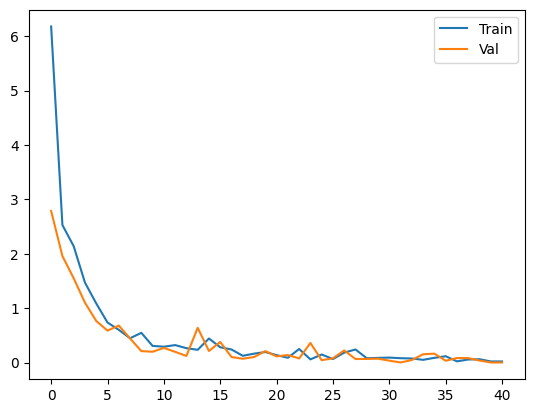

Epoch 42 | Train 0.0004 | Val 0.0004 | LR 1.25e-04
Epoch 43 | Train 0.0190 | Val 0.0161 | LR 1.22e-04
Epoch 44 | Train 0.0018 | Val 0.0270 | LR 1.19e-04
Epoch 45 | Train 0.0405 | Val 0.0025 | LR 1.16e-04
Epoch 46 | Train 0.0051 | Val 0.0079 | LR 1.13e-04
Epoch 47 | Train 0.0007 | Val 0.0159 | LR 1.09e-04
Epoch 48 | Train 0.0040 | Val 0.0044 | LR 1.06e-04
Epoch 49 | Train 0.0308 | Val 0.0907 | LR 1.03e-04
Epoch 50 | Train 0.0119 | Val 0.0000 | LR 1.00e-04
Epoch 51 | Train 0.0169 | Val 0.0000 | LR 9.69e-05


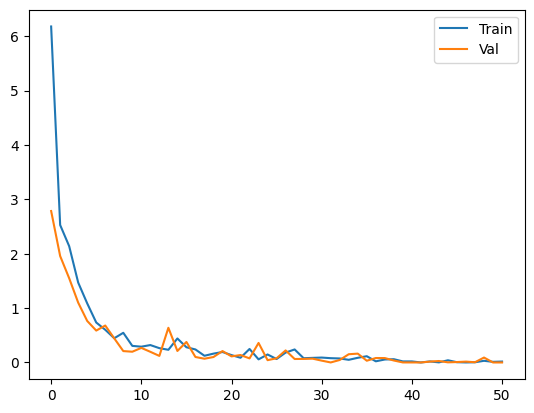

Epoch 52 | Train 0.0150 | Val 0.0838 | LR 9.37e-05
Epoch 53 | Train 0.0204 | Val 0.0006 | LR 9.06e-05
Epoch 54 | Train 0.0020 | Val 0.0045 | LR 8.75e-05
Epoch 55 | Train 0.0005 | Val 0.0000 | LR 8.44e-05
Epoch 56 | Train 0.0010 | Val 0.0089 | LR 8.13e-05
Epoch 57 | Train 0.0034 | Val 0.0005 | LR 7.82e-05
Epoch 58 | Train 0.0060 | Val 0.0009 | LR 7.51e-05
Epoch 59 | Train 0.0006 | Val 0.0001 | LR 7.21e-05
Epoch 60 | Train 0.0001 | Val 0.0001 | LR 6.91e-05
Epoch 61 | Train 0.0107 | Val 0.0000 | LR 6.61e-05


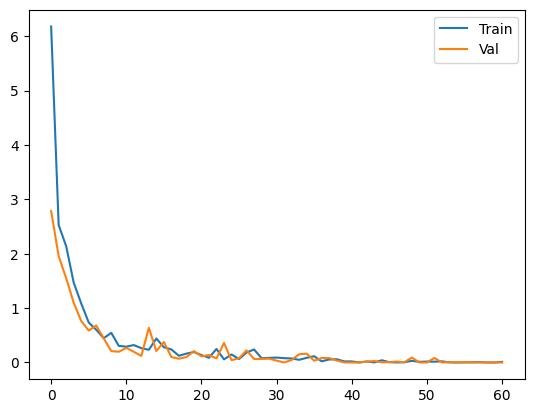

Epoch 62 | Train 0.0015 | Val 0.0000 | LR 6.32e-05
Epoch 63 | Train 0.0002 | Val 0.0003 | LR 6.03e-05
Epoch 64 | Train 0.0077 | Val 0.0001 | LR 5.74e-05
Epoch 65 | Train 0.0007 | Val 0.0000 | LR 5.46e-05
Epoch 66 | Train 0.0015 | Val 0.0001 | LR 5.18e-05
Epoch 67 | Train 0.0004 | Val 0.0000 | LR 4.91e-05
Epoch 68 | Train 0.0097 | Val 0.0000 | LR 4.64e-05
Epoch 69 | Train 0.0003 | Val 0.0000 | LR 4.38e-05
Epoch 70 | Train 0.0003 | Val 0.0000 | LR 4.12e-05
Epoch 71 | Train 0.0009 | Val 0.0000 | LR 3.87e-05


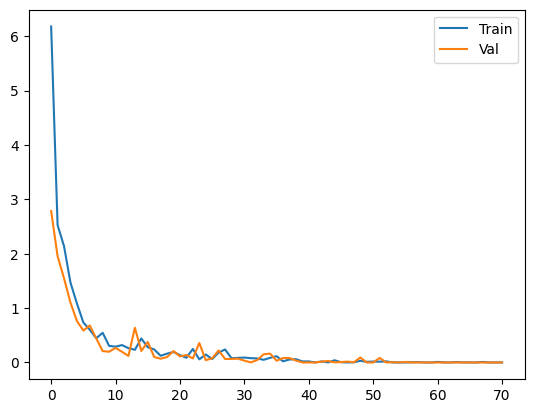

Epoch 72 | Train 0.0001 | Val 0.0000 | LR 3.63e-05
Epoch 73 | Train 0.0001 | Val 0.0000 | LR 3.39e-05
Epoch 74 | Train 0.0001 | Val 0.0000 | LR 3.15e-05
Epoch 75 | Train 0.0001 | Val 0.0000 | LR 2.93e-05
Epoch 76 | Train 0.0002 | Val 0.0000 | LR 2.71e-05
Epoch 77 | Train 0.0003 | Val 0.0000 | LR 2.50e-05
Epoch 78 | Train 0.0001 | Val 0.0000 | LR 2.29e-05
Epoch 79 | Train 0.0000 | Val 0.0000 | LR 2.10e-05
Epoch 80 | Train 0.0000 | Val 0.0000 | LR 1.91e-05
Epoch 81 | Train 0.0000 | Val 0.0000 | LR 1.73e-05


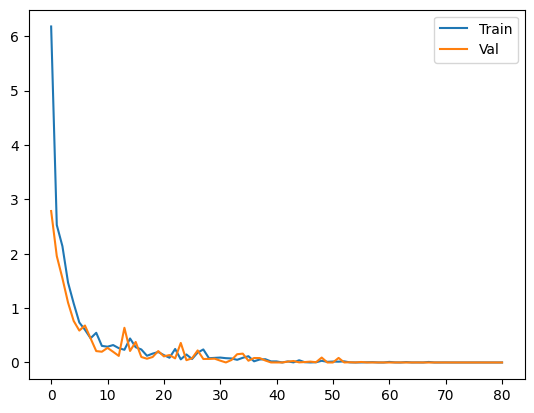

Epoch 82 | Train 0.0000 | Val 0.0000 | LR 1.56e-05
Epoch 83 | Train 0.0000 | Val 0.0000 | LR 1.39e-05
Epoch 84 | Train 0.0000 | Val 0.0000 | LR 1.24e-05
Epoch 85 | Train 0.0001 | Val 0.0000 | LR 1.09e-05
Epoch 86 | Train 0.0000 | Val 0.0000 | LR 9.52e-06
Epoch 87 | Train 0.0000 | Val 0.0000 | LR 8.22e-06
Epoch 88 | Train 0.0000 | Val 0.0000 | LR 7.02e-06
Epoch 89 | Train 0.0000 | Val 0.0000 | LR 5.91e-06
Epoch 90 | Train 0.0002 | Val 0.0000 | LR 4.89e-06
Epoch 91 | Train 0.0000 | Val 0.0000 | LR 3.97e-06


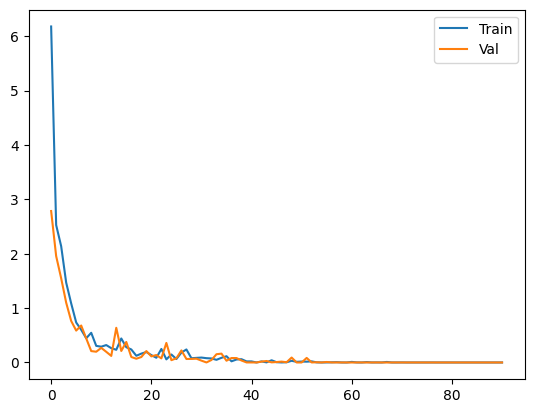

Epoch 92 | Train 0.0001 | Val 0.0000 | LR 3.14e-06
Epoch 93 | Train 0.0000 | Val 0.0000 | LR 2.41e-06
Epoch 94 | Train 0.0000 | Val 0.0000 | LR 1.77e-06
Epoch 95 | Train 0.0000 | Val 0.0000 | LR 1.23e-06
Epoch 96 | Train 0.0000 | Val 0.0000 | LR 7.89e-07
Epoch 97 | Train 0.0000 | Val 0.0000 | LR 4.44e-07
Epoch 98 | Train 0.0000 | Val 0.0000 | LR 1.97e-07
Epoch 99 | Train 0.0000 | Val 0.0000 | LR 4.93e-08
Epoch 100 | Train 0.0000 | Val 0.0000 | LR 0.00e+00


In [260]:
# Split data
train_size = int(0.8 * len(full_ds))
val_size = len(full_ds) - train_size
train_ds, val_ds = torch.utils.data.random_split(full_ds, [train_size, val_size])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# Models & optimizer
img_enc = ImageEncoder().to(device)
txt_enc = TextEncoder(VOCAB_SIZE, EMBED_DIM).to(device)
params = list(img_enc.parameters()) + list(txt_enc.parameters())
optimizer = torch.optim.AdamW(params, lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, EPOCH)

train_losses, val_losses = [], []

for epoch in range(EPOCH):
    # Train
    img_enc.train(); txt_enc.train()
    train_loss = 0
    for imgs, toks in train_loader:
        imgs, toks = imgs.to(device), toks.to(device)

        img_emb = img_enc(imgs)
        txt_emb = txt_enc(toks)

        loss = contrastive_loss(img_emb, txt_emb, TEMPERATURE)
        optimizer.zero_grad()
        loss.backward()

        # Grad clipping & norm check
        grad_norm = torch.nn.utils.clip_grad_norm_(params, 1.0)
        if grad_norm.item() < 1e-6:
            print(f"Warning: Vanishing gradients at epoch {epoch}")

        optimizer.step()
        train_loss += loss.item()

    scheduler.step()

    # Val
    img_enc.eval(); txt_enc.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, toks in val_loader:
            imgs, toks = imgs.to(device), toks.to(device)
            img_emb = img_enc(imgs)
            txt_emb = txt_enc(toks)
            val_loss += contrastive_loss(img_emb, txt_emb, TEMPERATURE).item()

    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)
    train_losses.append(avg_train); val_losses.append(avg_val)

    print(f"Epoch {epoch+1:02d} | Train {avg_train:.4f} | Val {avg_val:.4f} | LR {scheduler.get_last_lr()[0]:.2e}")

    if epoch % 10 == 0:
        plt.plot(train_losses, label='Train'); plt.plot(val_losses, label='Val')
        plt.legend(); plt.show()

# Display Embedding after training

Sample image and caption for embedding vizualization:'orange rectangle right' 


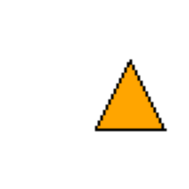

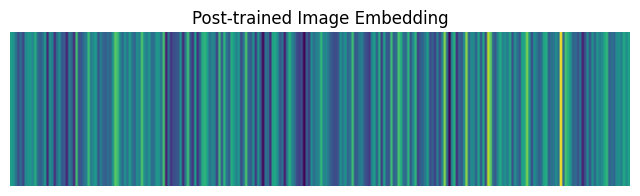

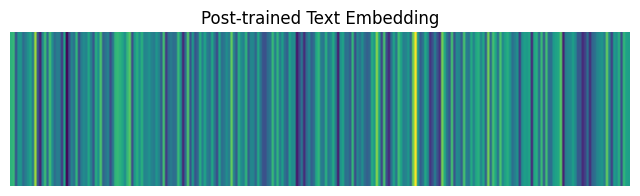

In [261]:
img_enc.eval(); txt_enc.eval()
with torch.no_grad():
  sample_img, sample_tok = full_ds[random_idx]
  sample_cap = full_ds.captions[random_idx]
  sample_img=sample_img.unsqueeze(0).to(device)
  sample_tok=sample_tok.unsqueeze(0).to(device)





post_train_img_emb=img_enc(sample_img).squeeze(0).cpu().detach().numpy()
post_train_txt_emb=txt_enc(sample_tok).squeeze(0).cpu().detach().numpy()


print(f"Sample image and caption for embedding vizualization:'{sample_cap}' ")
show_img(sample_img.squeeze(0).cpu())

plot_embedding(post_train_img_emb,'Post-trained Image Embedding')
plot_embedding(post_train_txt_emb,"Post-trained Text Embedding")

In [262]:
print("\n Dot product between text and image embedding:")
print(f"Before Training {np.dot(pre_train_img_emb,pre_train_txt_emb)}")
print(f"After Training {np.dot(post_train_img_emb,post_train_txt_emb)}")



 Dot product between text and image embedding:
Before Training -0.9940759539604187
After Training 8.967345237731934


### 3D Visualization of Embeddings after Training